# Mohajer m vs NDCG@10 on TREC-COVID

Sweep the Mohajer ranker's `m` parameter and measure how it affects NDCG@10 on the TREC-COVID reranking matrix. All runs reuse the same seed and cached data so only the sampling budget controlled by `m` is changing.


In [1]:
from typing import Sequence

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ireranker.data.loaders import load_beir_dataset
from ireranker.evaluation.beir import evaluate_rankers_beir
from ireranker.rankers import get_ranker

plt.style.use('ggplot')


2025-11-28 17:47:13.557 | INFO     | ireranker.config:<module>:14 - PROJ_ROOT path is: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker


In [2]:
from pathlib import Path
import json

CONFIG_PATH = Path('../config/beir_eval.json').resolve()
cfg = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}
ALL_DATASETS = [d.lower() for d in cfg.get('datasets', [])]
LIGHT_EXCLUDE = {d.lower() for d in cfg.get('light_exclude', [])}
LIGHT_DATASETS = [d for d in ALL_DATASETS if d not in LIGHT_EXCLUDE]

SEEDS = [42]
K_VALUES = [10]
M_VALUES = np.linspace(0, 2, 50)

print('Datasets (light mode):', ', '.join(LIGHT_DATASETS))
print(f'Running {len(SEEDS)} seeds: {SEEDS}')


Datasets (light mode): webis-touche2020, trec-covid, scifact
Running 1 seeds: [42]


In [3]:
def evaluate_m_values(dataset_name: str, m_values: Sequence[float], seeds: Sequence[int]) -> pd.DataFrame:
    dataset = load_beir_dataset(dataset_name, split='test')
    rows = []
    for seed in seeds:
        for m in m_values:
            ranker = get_ranker('mohajer (ir)', seed=seed)
            ranker.m = m
            ranker.set_dataset(dataset_name, split='test')
            result = evaluate_rankers_beir([ranker], dataset, K_VALUES, seed=seed)[0]
            rows.append({
                'dataset': dataset_name,
                'seed': seed,
                'm': m,
                'NDCG@10': float(result['NDCG']),
                'MAP@10': float(result['MAP']),
                'Recall@10': float(result['Recall']),
                'P@10': float(result['Precision']),
                'Comparisons': int(result['Comparisons']),
                'NDCG_per_comp': float(result['NDCG_per_comp']),
            })
    return pd.DataFrame(rows).sort_values(['dataset', 'seed', 'm']).reset_index(drop=True)

m_sweep_df = pd.concat(
    [evaluate_m_values(ds, M_VALUES, SEEDS) for ds in LIGHT_DATASETS],
    ignore_index=True,
)
m_sweep_df


/home/jerefigo/.local/lib/python3.10/site-packages/beir/util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


2025-11-28 17:47:15.464 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/webis-touche2020
2025-11-28 17:47:17.784 | INFO     | ireranker.data.loaders:_load_rerank_matrix:172 - Loaded rerank matrix for webis-touche2020/test (queries: 49)
2025-11-28 17:47:17.785 | INFO     | ireranker.data.loaders:load_beir_dataset:264 - Using rerank matrix for 49 queries in webis-touche2020/test
2025-11-28 17:47:17.787 | INFO     | ireranker.data.loaders:load_beir_dataset:274 - Query coverage for webis-touche2020/test -> matrix: 49, qrels: 49, shared: 49, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  4.84it/s]


2025-11-28 17:47:24.657 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/trec-covid
2025-11-28 17:47:26.519 | INFO     | ireranker.data.loaders:_load_rerank_matrix:172 - Loaded rerank matrix for trec-covid/test (queries: 50)
2025-11-28 17:47:26.519 | INFO     | ireranker.data.loaders:load_beir_dataset:264 - Using rerank matrix for 50 queries in trec-covid/test
2025-11-28 17:47:26.560 | INFO     | ireranker.data.loaders:load_beir_dataset:274 - Query coverage for trec-covid/test -> matrix: 50, qrels: 50, shared: 50, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  4.59it/s]


2025-11-28 17:47:33.917 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/scifact
2025-11-28 17:47:50.387 | INFO     | ireranker.data.loaders:_load_rerank_matrix:172 - Loaded rerank matrix for scifact/test (queries: 300)
2025-11-28 17:47:50.390 | INFO     | ireranker.data.loaders:load_beir_dataset:264 - Using rerank matrix for 300 queries in scifact/test
2025-11-28 17:47:50.405 | INFO     | ireranker.data.loaders:load_beir_dataset:274 - Query coverage for scifact/test -> matrix: 300, qrels: 300, shared: 300, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:01<00:00,  1.26s/it]


,dataset,seed,m,NDCG@10,MAP@10,Recall@10,P@10,Comparisons,NDCG_per_comp
0,webis-touche2020,42,0.000000,0.08054,0.02873,0.09587,0.08980,0,0.000000
1,webis-touche2020,42,0.040816,0.10570,0.03535,0.09749,0.10204,437,0.000242
2,webis-touche2020,42,0.081633,0.10506,0.03720,0.09211,0.09184,883,0.000119
3,webis-touche2020,42,0.122449,0.09895,0.03544,0.10067,0.10408,1488,0.000066
4,webis-touche2020,42,0.163265,0.13302,0.04804,0.12723,0.12653,2034,0.000065
...,...,...,...,...,...,...,...,...,...
145,scifact,42,1.836735,0.67089,0.61726,0.82019,0.09176,131066,0.000005
146,scifact,42,1.877551,0.68244,0.63189,0.82348,0.09319,134019,0.000005
147,scifact,42,1.918367,0.68419,0.63666,0.81810,0.09247,137095,0.000005
148,scifact,42,1.959184,0.68246,0.63394,0.81959,0.09247,140311,0.000005


In [4]:
best_overall = m_sweep_df.loc[m_sweep_df['NDCG@10'].idxmax()]
mean_by_ds = m_sweep_df.groupby(['dataset', 'm'])['NDCG@10'].mean().reset_index()
best_by_dataset = mean_by_ds.loc[mean_by_ds.groupby('dataset')['NDCG@10'].idxmax()]
best_overall, best_by_dataset[['dataset', 'm', 'NDCG@10']]


(dataset          trec-covid
 seed                     42
 m                  1.183673
 NDCG@10             0.80328
 MAP@10              0.20683
 Recall@10           0.23257
 P@10                  0.834
 Comparisons           13836
 NDCG_per_comp      0.000058
 Name: 79, dtype: object,
               dataset         m  NDCG@10
 36            scifact  1.469388  0.70255
 79         trec-covid  1.183673  0.80328
 149  webis-touche2020  2.000000  0.31415)

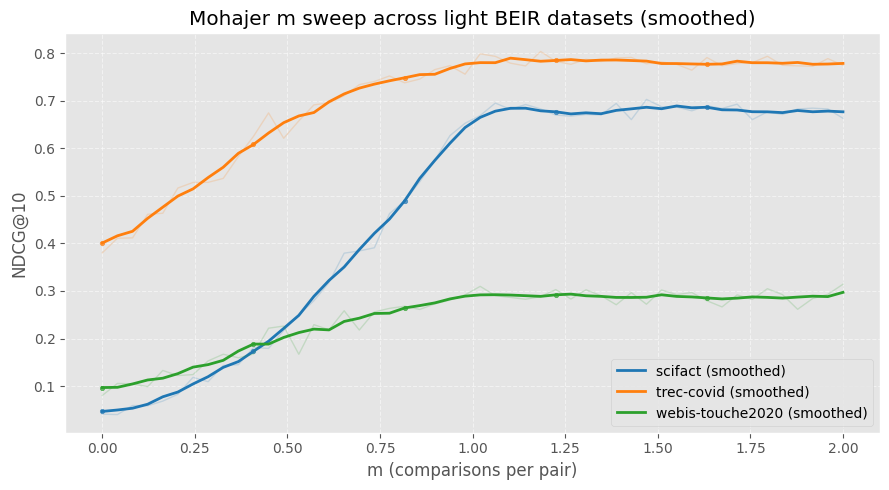

In [5]:
mean_by_ds = (
    m_sweep_df.groupby(['dataset', 'm'])['NDCG@10'].agg(['mean', 'std']).reset_index()
    .sort_values(['dataset', 'm'])
)

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(9, 5))
for idx, (ds, sub) in enumerate(mean_by_ds.groupby('dataset')):
    color = colors[idx % len(colors)]
    smoothed = sub['mean'].rolling(window=5, center=True, min_periods=1).mean()
    ax.plot(sub['m'], smoothed, linewidth=2, color=color, label=f"{ds} (smoothed)")
    ax.plot(sub['m'], sub['mean'], color=color, alpha=0.18, linewidth=1)
    ax.scatter(sub['m'][::10], smoothed.iloc[::10], color=color, s=10, alpha=0.7)
    if sub['std'].notna().any():
        lower = smoothed - sub['std']
        upper = smoothed + sub['std']
        ax.fill_between(sub['m'], lower, upper, color=color, alpha=0.06)

ax.set_xlabel('m (comparisons per pair)')
ax.set_ylabel('NDCG@10')
ax.set_title('Mohajer m sweep across light BEIR datasets (smoothed)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


- Reuse the cached rerank matrix under `data/external/reranking-matrices` and the BEIR dataset cache under `data/external/beir`.
- Adjust `M_VALUES` to try different sampling budgets or add finer granularity.
- Keep the seed fixed when you want to compare only the effect of `m`; change it to check robustness across random draws.
